In [1]:
import tables
from ctapipe.visualization import CameraDisplay
from ctapipe.coordinates import EngineeringCameraFrame
from ctapipe_io_lst import LSTEventSource
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# CAMERA GEOMETRY------ 
sa = LSTEventSource.create_subarray(tel_id=1)
focal_length = sa.tel[1].optics.equivalent_focal_length
camera_geom = sa.tel[1].camera.geometry

# ROBUST FIT FUNCTION 
def robust_fitt(x, y, z_thresh=3.5):
    X = x.astype(float).reshape(-1, 1)
    Xc = sm.add_constant(X)
    fit = np.zeros_like(y, dtype=float)
    slope = np.zeros(y.shape[1])
    u_slope = np.zeros(y.shape[1])
    intercept = np.zeros(y.shape[1])
    u_intercept = np.zeros(y.shape[1])
    R2 = np.zeros(y.shape[1]) 
    good_points = []
    valid = []  # True/False per column
    good_masks = [] #to get the positions of the good points

    for p in range(y.shape[1]):
        yp = y[:, p]
        model = sm.OLS(yp, Xc).fit()
        residual = np.abs(yp - model.predict(Xc))
        mad = np.median(np.abs(residual - np.median(residual)))
        mad = max(mad, 1e-12)  # avoid division by zero
        modified_z = 0.6745 * residual / mad
        good = modified_z <= z_thresh
        good_masks.append(good)
        
        if good.sum() >= 0.6*len(x):  # if we take only 2 points, the line of the fit will cross them exactly, giving sigma=0 (both residuals=0)
            good_points.append((x[good], yp[good]))
            
            model = sm.OLS(yp[good], Xc[good]).fit()
            fit[:, p] = model.predict(Xc)
            intercept[p] = model.params[0]
            slope[p] = model.params[1]
            u_intercept[p] = model.bse[0]
            u_slope[p] = model.bse[1]
            R2[p] = (model.rsquared) 
            valid.append(True)
            
        else:
            good_points.append((None, None))
            fit[:, p] = np.nan
            intercept[p] = np.nan
            slope[p] = np.nan
            u_intercept[p] = np.nan
            u_slope[p] = np.nan
            R2[p] = np.nan
            valid.append(False)
        

    return {"fit": fit, "slope": slope, "u_slope": u_slope,
            "intercept": intercept, "u_intercept": u_intercept,
            "good_points": good_points, "good_mask": good_masks, "valid": valid, "R2": R2}

run_id = 20767

# READING RESULTS -------------------------------------------------------------------------------------------------------------------------------
b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/checks_h5/checks_Run{run_id}.h5".format(run_id= run_id))

for filt in ["filter1", "filter2", "filter2a", "filter2b", "filter2c"]:

    table = getattr(b.root.perfilter, filt)
    
    print(f"\n{'='*60}")
    print(f"{filt.upper()}")
    print(f"{'='*60}")
    
    if len(table) == 0:
        print("No checks found.")
        continue

    sigma_cutoff = table[0]["sigma_cutoff"]     
    print(f"Sigma cutoff = {sigma_cutoff}")
    
    fit = table[0]["fit_parameters"]
    slope, u_slope, intercept, u_intercept = fit
    
    print("Fit parameters:")
    print(f"  slope     = {slope:.6f} ± {u_slope:.6f}")
    print(f"  intercept = {intercept:.6f} ± {u_intercept:.6f}")
    
    print("\nChecks:")
    print(f"{'Subrun':>8} {'z-score':>10}")
    print("-" * 20)
    
    for row in table:
        print(f"{row['check_index']:>8} {row['z_score']:>10.3f}")

    
print("\nCoincident checks:")

table = b.root.general.coincident_checks

if len(table) == 0:
    print("  None")
else:
    for row in table:
        print(f"  {row['check_index']}")


FILTER1
Sigma cutoff = 50.0
Fit parameters:
  slope     = -2.932000 ± 0.218212
  intercept = 6501.075817 ± 8.491834

Checks:
  Subrun    z-score
--------------------
      44   2528.976

FILTER2
Sigma cutoff = 10.0
Fit parameters:
  slope     = -0.000016 ± 0.000014
  intercept = 0.006158 ± 0.000538

Checks:
  Subrun    z-score
--------------------
      13     13.254
      14     16.072
      15     12.515
      16     16.990

FILTER2A
Sigma cutoff = 6.0
Fit parameters:
  slope     = -0.000005 ± 0.000017
  intercept = 0.007233 ± 0.000676

Checks:
  Subrun    z-score
--------------------
      13     19.259
      14     14.162
      15     12.578
      16     22.135

FILTER2B
No checks found.

FILTER2C
No checks found.

Coincident checks:
  13
  14
  15
  16


/data/cta/software/conda/miniforge3/envs/lstchain-v0.12.3/lib/python3.11/site-packages/ctapipe/core/provenance.py:280: MissingReferenceMetadata: Could not read reference metadata for input file: /data/cta/software/conda/miniforge3/envs/lstchain-v0.12.3/lib/python3.11/site-packages/ctapipe_io_lst/resources/oversampled_pulse_LST_8dynode_pix6_20200204.dat
  warnings.warn(


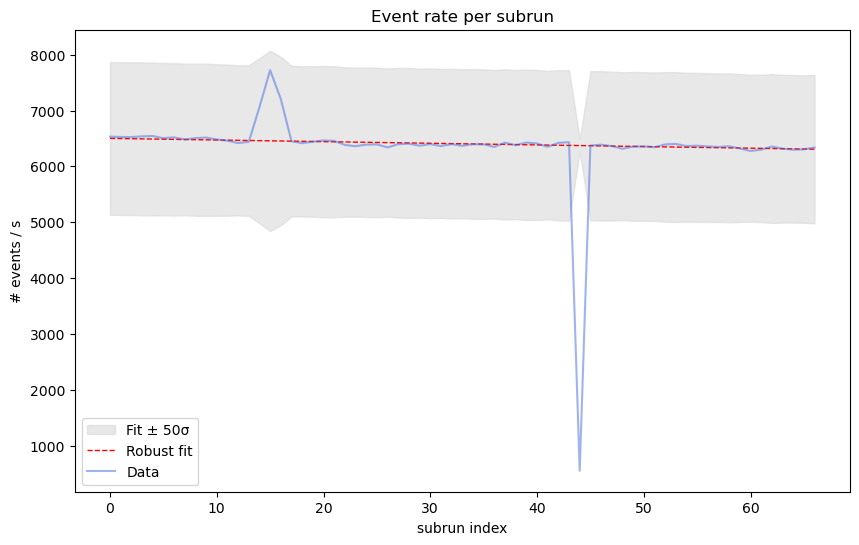

In [2]:
# FILTERS REVISION-------------------------------------------------------------------------------------------------------------------------------------------
#a = tables.open_file("/data/cta/users-ifae/summer_students/agl/datacheck_dl1_LST-1.Run24704.h5")
a = tables.open_file(r"/data/cta/users-ifae/moralejo/CTA/summer_student_2026/datacheck/ALL_h5/datacheck_dl1_LST-1.Run{run_id}.h5".format(run_id= run_id))

subruns = a.root.dl1datacheck.cosmics.col('subrun_index')[:-1] #0,1,...,57 number of subruns in this run
n_subruns = len(subruns)
time = a.root.dl1datacheck.cosmics.col('elapsed_time')[:-1]

# FILTER 1------------------------------------------------------------------------
num_events = a.root.dl1datacheck.cosmics.col('num_events')[:-1] # events in each subrun
event_rate = num_events / time
event_rate_sigma = np.sqrt(np.maximum(num_events, 1.0)) / time  

# ROBUST FIT
event_rate_robfit = robust_fitt(subruns, event_rate.reshape(-1, 1))
event_rate_fit = event_rate_robfit["fit"].flatten()
sigma_cutoff_1 = 50

plt.figure(figsize=(10, 6))
plt.fill_between(
    subruns,
    event_rate_fit - sigma_cutoff_1 * event_rate_sigma,
    event_rate_fit + sigma_cutoff_1* event_rate_sigma,
    color='lightgray', alpha= 0.5, label=f'Fit ± {sigma_cutoff_1}σ'
)
plt.plot(subruns, event_rate_fit, label='Robust fit', color='red', linestyle='--', linewidth=1)
plt.plot(subruns, event_rate, color='royalblue', alpha=0.5, label='Data')
plt.title('Event rate per subrun')
plt.ylabel('# events / s')
plt.xlabel('subrun index')
plt.legend()
plt.show()



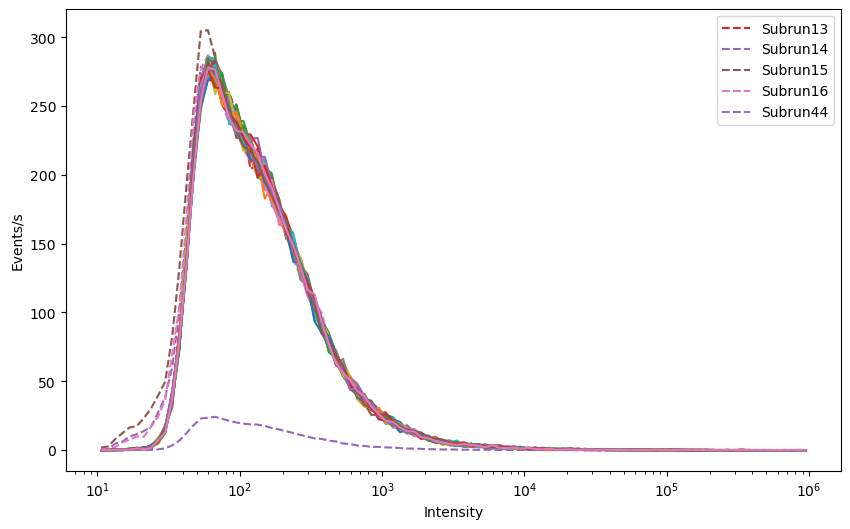

NameError: name 'sigma_cutoff_2a' is not defined

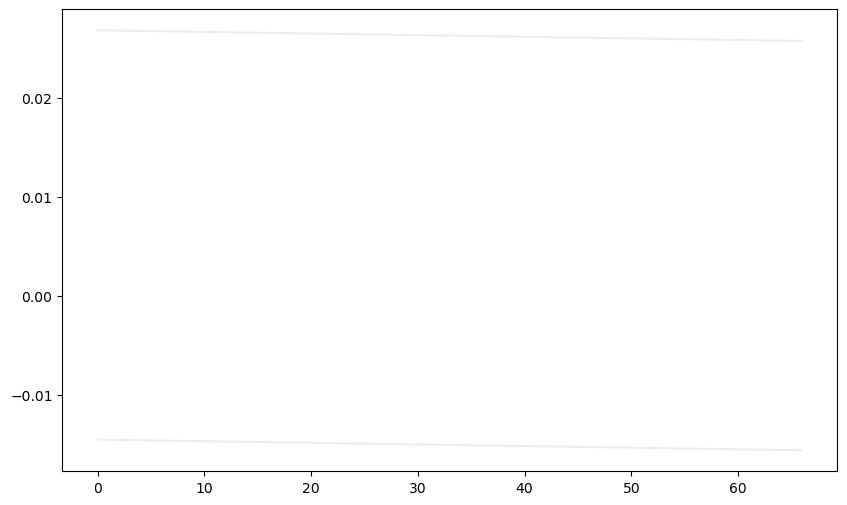

In [3]:
# FILTER 2: EVENT RATE VS INTENSITY------------------------------------------------------
hist_intensity = a.root.dl1datacheck.cosmics.col('hist_intensity')[:-1]
intensity_bins = a.root.dl1datacheck.histogram_binning.col('hist_intensity')[0]
intensity = 0.5*(intensity_bins[1:]+intensity_bins[:-1])  

cdf = np.cumsum(hist_intensity / np.maximum(hist_intensity.sum(axis=1, keepdims=True),1), axis=1)   #we need to normalize the histogram. 1 cdf per subrun
D = np.zeros(n_subruns) 

for s in range(0, n_subruns-1):
    D[s] = np.max(np.abs(cdf[s] - cdf[s+1])) #we compare the CDF in each subrun 's' with its neighbouring one 's+1'

#Do a robust fit of D to select the good points
D_robust_fit = robust_fitt(subruns, D.reshape(-1, 1))
sigma_cutoff_2 = 10 # for the selection criteria

D_good = D_robust_fit["good_points"][0][1]  # y-selected values for this column
D_fit = D_robust_fit["fit"].flatten()       

good_mask_2 = D_robust_fit["good_mask"][0]               
D_fit_good = D_fit[good_mask_2]                # take the fit only at the 'good points' to calculate the sigmas

sigma_2 = np.std(D_good - D_fit_good) # calculate the sigma for those good points so that it is not biased 

# This is not a Poisson process therefore we cannot treat it as such

# PLOT INTENSITIES
checks = b.root.general.cosmics.col("subrun_index")
plt.figure(figsize=(10, 6))   

for s in range(hist_intensity.shape[0]):  
    event_rate_i = hist_intensity[s] / time[s]
    if s in checks:
        plt.plot(intensity, event_rate_i, linestyle='--', label=f'Subrun{s}')
    else:
         plt.plot(intensity, event_rate_i)

plt.legend()
plt.xlabel('Intensity')
plt.ylabel('Events/s')
plt.xscale('log')
plt.show()

# PLOT KOLMOGOROV
plt.figure(figsize=(10, 6))
plt.plot(subruns, D_fit + sigma_cutoff_2 * sigma_2, color='lightgray', alpha= 0.4, label=f'Fit ± {sigma_cutoff_2}σ F2')
plt.plot(subruns, D_fit - sigma_cutoff_2 * sigma_2, color='lightgray', alpha= 0.4)
plt.plot(subruns, D_fit + sigma_cutoff_2a * sigma_2, color='blue', alpha= 0.4, label=f'Fit ± {sigma_cutoff_2a}σ F2a')
plt.plot(subruns, D_fit - sigma_cutoff_2a * sigma_2, color='blue', alpha= 0.4)
plt.plot(subruns, D_fit + sigma_cutoff_2b * sigma_2, color='orange', alpha= 0.4, label=f'Fit ± {sigma_cutoff_2b}σ F2b')
plt.plot(subruns, D_fit - sigma_cutoff_2b * sigma_2, color='orange', alpha= 0.4)
plt.plot(subruns, D_fit + sigma_cutoff_2c * sigma_2, color='green', alpha= 0.4, label=f'Fit ± {sigma_cutoff_2c}σ F2b')
plt.plot(subruns, D_fit - sigma_cutoff_2c * sigma_2, color='green', alpha= 0.4)


plt.plot(subruns, D_fit, label='Robust fit', color='red', linestyle='--')
plt.plot(subruns, D, linewidth=1, color='lightblue', label='D Kolmogorov')
plt.scatter(D_robust_fit["good_points"][0][0], D_robust_fit["good_points"][0][1], label='selected', s=3)
plt.xlabel('Subrun')
plt.ylabel('D Kolmogorov')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



In [ ]:

for i in checks:
    camdisplay = CameraDisplay(camera_geom.transform_to(EngineeringCameraFrame()),
                          norm='lin', title=f'Rate of events with CoG in pixel subrun ¨{i}', 
                           image=(a.root.dl1datacheck.cosmics.col('cog_within_pixel')[:-1]/ time[:, None])[i,:])
    camdisplay.autoupdate = True
    camdisplay.add_colorbar()
    plt.show()



In [ ]:
# OTHER FILTERS SPECIFIC FOR SATELLITES

In [ ]:
print(focal_length.value)
print(focal_length.value*np.tan(np.radians(0.05))*100) 

/data/cta/software/conda/miniforge3/envs/lstchain-v0.12.3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Subruns to check = 15


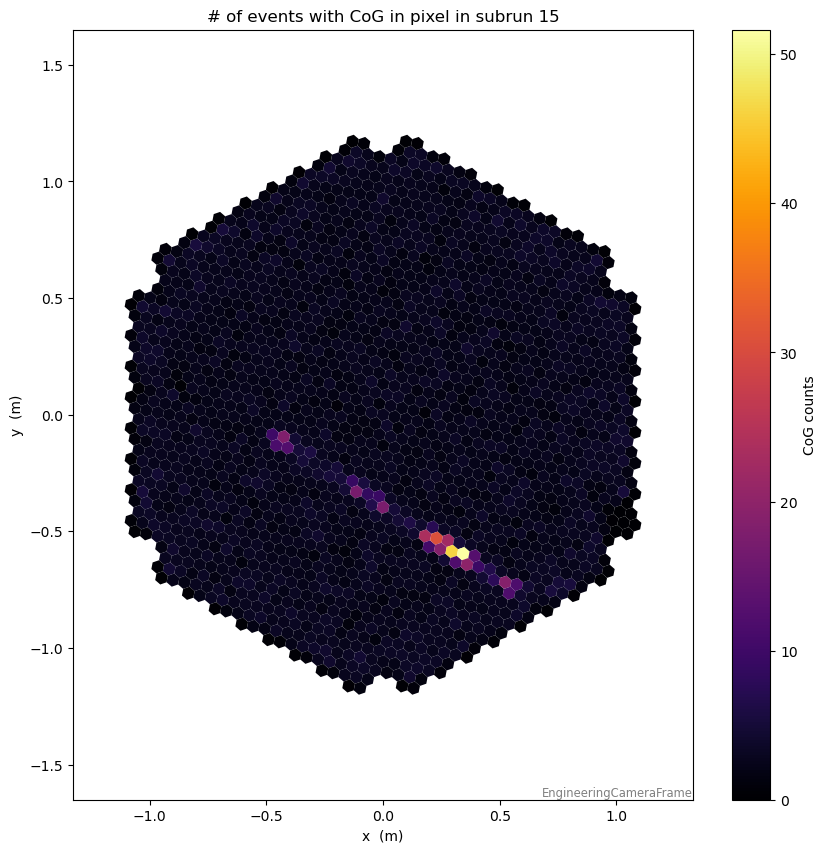

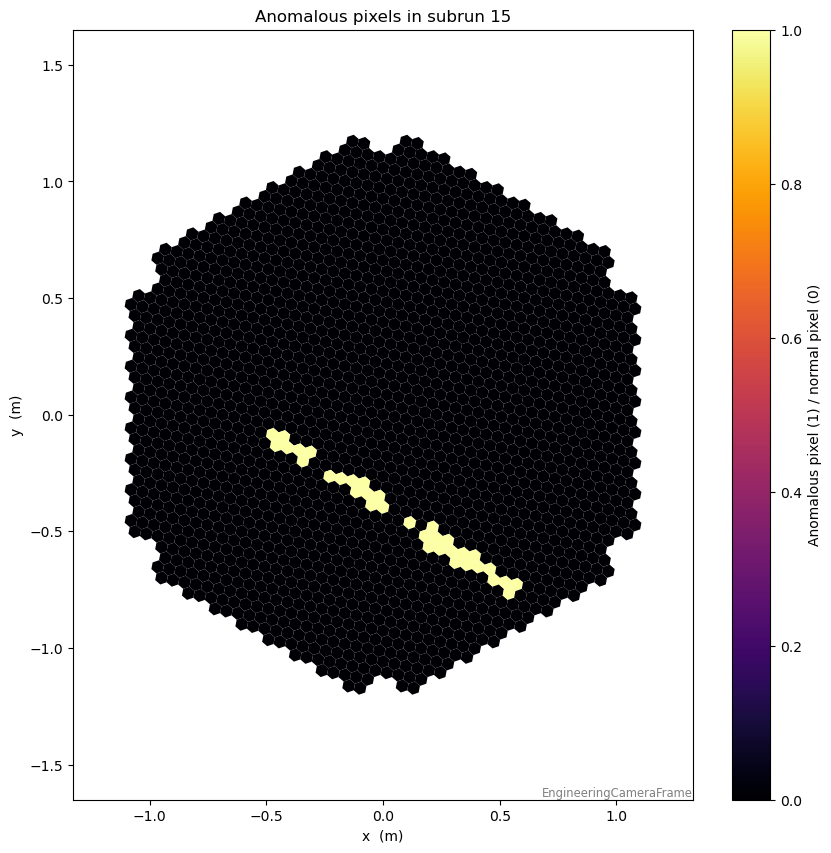

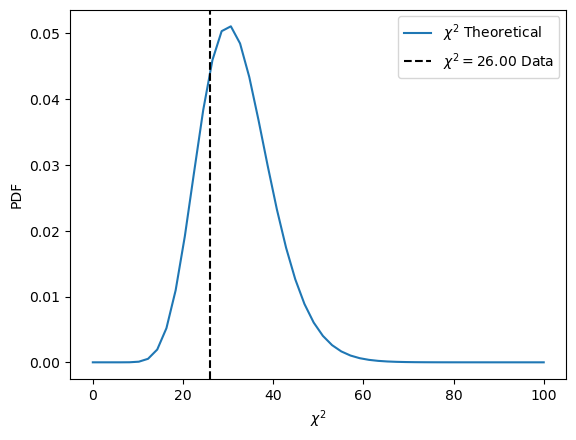

p-value = 7.637e-01


In [8]:
# FILTER 3: FLUCTUATIONS OF CoG WITHIN PIXEL
from sklearn.decomposition import PCA
from shapely.geometry import LineString, Point
from scipy.stats import chi2

cog_pixel = a.root.dl1datacheck.cosmics.col('cog_within_pixel')[:-1]  # shape: (n_subruns, n_pixels)

cog_rate = cog_pixel / time[:, None]
cog_sigma = np.sqrt(np.maximum(cog_pixel, 1.0)) / time[:, None] # Poisson-like uncertainty associated to each value


# 3.1: ROBUST FIT TO SELECT PIXELS IN WHICH THE ANOMALY HAS FALLEN 
cog_fit = robust_fitt(subruns, cog_rate)["fit"]

# Selection criteria
cog_z_score = (cog_rate - cog_fit) / cog_sigma
mask_3 = (cog_z_score) > 3 # when taking np.abs(z_score), much more anomalous pixels appear


# Select subrun interesting to check according to this filter
checks_3 = subruns[np.argmax(mask_3.sum(axis=1))]
print('Subruns to check =', checks_3)

anomaly_image = mask_3[checks_3].astype(int)

# Plot of CoG rate within pixel for anomalous subrun
plt.figure(figsize=(10, 10))
camdisplay = CameraDisplay(
    camera_geom.transform_to(EngineeringCameraFrame()),
    norm='lin',
    title=f'# of events with CoG in pixel in subrun {checks_3}',
    image=cog_rate[checks_3, :],
)
camdisplay.autoupdate = True
camdisplay.add_colorbar(label='CoG counts')
plt.show()


# 3.2: PCA FIT OF THE SELECTED PIXELS
# Linear fit to check that indeed the path is linear, x=-y y=-x
x_pixels = camera_geom.transform_to(EngineeringCameraFrame()).pix_x[mask_3[checks_3]].value  # .value to remove the units in the array, we need to transf to eng. camera frame to plot it correctly
y_pixels = camera_geom.transform_to(EngineeringCameraFrame()).pix_y[mask_3[checks_3]].value

m_pixels = np.column_stack((x_pixels, y_pixels)) #matrix of the shape columns: pixel, rows: x_pixel, y_pixel

pca = PCA(n_components=1)
pca.fit(m_pixels)

centroid = pca.mean_
direction_vector = pca.components_[0]

ax = camdisplay.axes

projection = (m_pixels - centroid) @ direction_vector # projection of the position of the pixels with respect to the centroid along the direction vector

t = np.linspace(projection.min(), projection.max(), 100) # drawing the line along the pixels used by the fit

x_pca = centroid[0] + t * direction_vector[0]
y_pca = centroid[1] + t * direction_vector[1]

# Plot of anomalous pixels in anomalous subrun + Linear fit of those pixels with PCA
plt.figure(figsize=(10, 10))
camdisplay = CameraDisplay(
    camera_geom.transform_to(EngineeringCameraFrame()),
    title=f'Anomalous pixels in subrun {checks_3}',
    image=anomaly_image,
)
camdisplay.add_colorbar(label='Anomalous pixel (1) / normal pixel (0)')

ax.plot(x_pca, y_pca, color="blue", lw=2, label="PCA fit")
ax.scatter(*centroid, color="blue", s=40, label="Centroid")
ax.legend()

plt.show()


# X^2 TEST TO DETERMINE IF THE PIXELS REALLY FOLLOW A STRAIGHT LINE

#Distances (orthogonal) from the center of the pixel to the fit
line = LineString([(x_pca[0], y_pca[0]), (x_pca[-1], y_pca[-1])])
distances = []

for x, y in zip(x_pixels, y_pixels):
    point = Point(x, y)
    distances.append(line.distance(point))

distances = np.array(distances)

# Pixel position uncertainty (choose the appropriate value)
sigma_pixel = (focal_length.value)*np.tan(np.radians(0.05)) # width of the pixel ~2.44 cm

# Chi-square
# Chi2 Calculated
chi2_data = np.sum((distances / sigma_pixel)**2)

# Chi2 Theoretical
dof = len(distances) - 2
x = np.linspace(0, 100)
chi2_th = chi2.pdf(x, dof)

plt.plot(x, chi2_th, label=fr"$\chi^2$ Theoretical")
plt.axvline(chi2_data, color="black", linestyle='--', label=fr"$\chi^2={chi2_data:.2f}$ Data")

plt.xlabel(r"$\chi^2$")
plt.ylabel("PDF")
plt.legend()
plt.show()

p_value = 1 - chi2.cdf(chi2_data, dof)

print(f"p-value = {p_value:.3e}")





# Trand to telescope
# por pixel 0.1º = u ancho y alto respecto al centro. comparar desde el centro de cada pixel con el fit , a que sitancia esta y dividir por 0.05 N putnos 2 parametros libres 
# chi^2, regresion con PCA scikit learn. preseleccionar con zscore 
